In [1]:
# Allow loading the `adaptive_cover_pro` module from this notebook
import sys

sys.path.append("../custom_components")

from datetime import date, timedelta  # noqa: F401
import pandas as pd
import numpy as np  # noqa: F401
import matplotlib.pyplot as plt  # noqa: F401

from adaptive_cover_pro.config_types import CoverConfig, VerticalConfig, HorizontalConfig  # type: ignore
from adaptive_cover_pro.engine.covers import AdaptiveVerticalCover, AdaptiveHorizontalCover  # type: ignore
from adaptive_cover_pro.sun import SunData  # type: ignore

# Adaptive Cover Algorithm Testing

This notebook provides interactive testing and visualization of the Adaptive Cover calculation algorithms.

## Purpose
- Test vertical and horizontal blind position calculations without requiring Home Assistant
- Visualize how cover positions change based on sun position throughout the day
- Experiment with configuration parameters before deploying

## How to Use
1. Modify configuration variables in the next cell (timezone, lat/lon, window properties)
2. Run all cells sequentially (Cell → Run All)
3. Review the plots showing sun position and calculated cover positions

## Output Interpretation
- **Red dashed lines:** Sunrise and sunset times
- **Yellow dashed lines:** Sun enters/exits the window's field of view
- **Blue/Orange lines (primary axis):** Sun elevation and azimuth angles
- **Green line (secondary axis):** Cover opening state (0% closed → 100% open)

Location

In [2]:
# Location settings
timezone = "America/Los_Angeles"
lat = 32.9390684322475   # Latitude in degrees
lon = -117.15618073940279  # Longitude in degrees

Integration Calculations

Saved vertical cover plot to outputs/vertical_cover_plot.png


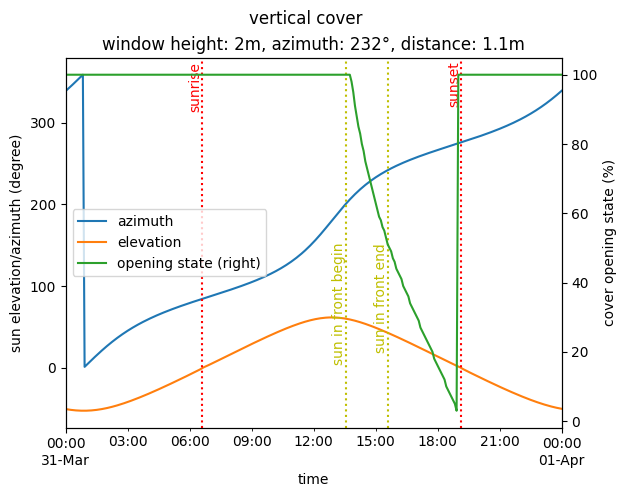

In [3]:
# ===== CONFIGURATION: Modify these values to test different scenarios =====

# Cover position limits
maximum_position = 100  # Maximum cover opening (0=closed, 100=open)

# Window physical properties
window_height = 2      # Window height in meters
shaded_area = 1.1      # Distance from window to blind in meters
window_azimuth = 232   # Window azimuth (0=North, 90=East, 180=South, 270=West)
window_fov_left = 32   # Field of view to the left in degrees
window_fov_right = 10  # Field of view to the right in degrees

# Default behavior
default_height = 60  # Default cover position percentage when sun not in front

from astral import LocationInfo  # noqa: E402
from astral.location import Location  # noqa: E402


class MockedLogger:
    """Mock logger for notebook testing."""

    config_name = "Notebook Test"

    def debug(self, msg, *args, **kwargs): pass  # noqa: D102
    def info(self, msg, *args, **kwargs): pass  # noqa: D102
    def warning(self, msg, *args, **kwargs): pass  # noqa: D102
    def error(self, msg, *args, **kwargs): pass  # noqa: D102


mocked_logger = MockedLogger()

# Build astral Location directly (no HA dependency)
_loc_info = LocationInfo(
    name="Test",
    region="",
    timezone=timezone,
    latitude=lat,
    longitude=lon,
)
astral_location = Location(_loc_info)
astral_elevation = 0

sun_data = SunData(timezone, astral_location, astral_elevation)
sunrise_time = sun_data.location.sunrise()
sunset_time = sun_data.location.sunset()

sun_df = pd.DataFrame(
    {
        "azimuth": sun_data.solar_azimuth,
        "elevation": sun_data.solar_elevation,
    }
)
sun_df.set_index(sun_data.times, inplace=True)


# Shared CoverConfig for all covers
cover_config = CoverConfig(
    win_azi=window_azimuth,
    fov_left=window_fov_left,
    fov_right=window_fov_right,
    h_def=default_height,
    sunset_pos=30,
    sunset_off=0,
    sunrise_off=0,
    max_pos=maximum_position,
    min_pos=0,
    max_pos_sun_only=False,
    min_pos_sun_only=False,
    blind_spot_left=None,
    blind_spot_right=None,
    blind_spot_elevation=None,
    blind_spot_on=False,
    min_elevation=None,
    max_elevation=None,
)

vert_config = VerticalConfig(
    distance=shaded_area,
    h_win=window_height,
)


def compute_vertical_position(row):
    """Compute vertical cover position for a single time step."""
    _sun = SunData(timezone, astral_location, astral_elevation)
    cover = AdaptiveVerticalCover(
        logger=mocked_logger,
        sol_azi=row["azimuth"],
        sol_elev=row["elevation"],
        sun_data=_sun,
        config=cover_config,
        vert_config=vert_config,
    )
    return cover.calculate_percentage(), cover.valid


sun_df[["opening state", "sun_is_on"]] = sun_df.apply(
    compute_vertical_position, axis=1, result_type="expand"
)

sun_in_front_begin = sun_df[sun_df["sun_is_on"]].iloc[0].name.to_pydatetime()
sun_in_front_end = sun_df[sun_df["sun_is_on"]].iloc[-1].name.to_pydatetime()


def plot(suptitle: str):
    """Plot sun position and cover state."""
    ax = sun_df.plot(
        secondary_y=["opening state"],
        title=f"window height: {window_height}m, azimuth: {window_azimuth}°, distance: {shaded_area}m",
    )
    ax.set_ylabel("sun elevation/azimuth (degree)")
    ax.right_ax.set_ylabel("cover opening state (%)")
    ax.figure.suptitle(suptitle)
    ax.axvline(sunrise_time, color="r", ls=":")
    ax.text(sunrise_time, 0.99, "sunrise", color="r", ha="right", va="top",
            rotation=90, transform=ax.get_xaxis_transform())
    ax.axvline(sun_in_front_begin, color="y", ls=":")
    ax.text(sun_in_front_begin, 0.5, "sun in front begin", color="y", ha="right",
            va="top", rotation=90, transform=ax.get_xaxis_transform())
    ax.axvline(sunset_time, color="r", ls=":")
    ax.text(sunset_time, 0.99, "sunset", color="r", ha="right", va="top",
            rotation=90, transform=ax.get_xaxis_transform())
    ax.axvline(sun_in_front_end, color="y", ls=":")
    ax.text(sun_in_front_end, 0.5, "sun in front end", color="y", ha="right",
            va="top", rotation=90, transform=ax.get_xaxis_transform())


plot("vertical cover")

import os  # noqa: E402
os.makedirs("outputs", exist_ok=True)
plt.savefig("outputs/vertical_cover_plot.png", dpi=150, bbox_inches="tight")
print("Saved vertical cover plot to outputs/vertical_cover_plot.png")  # noqa: T201

Saved horizontal cover plot to outputs/horizontal_cover_plot.png


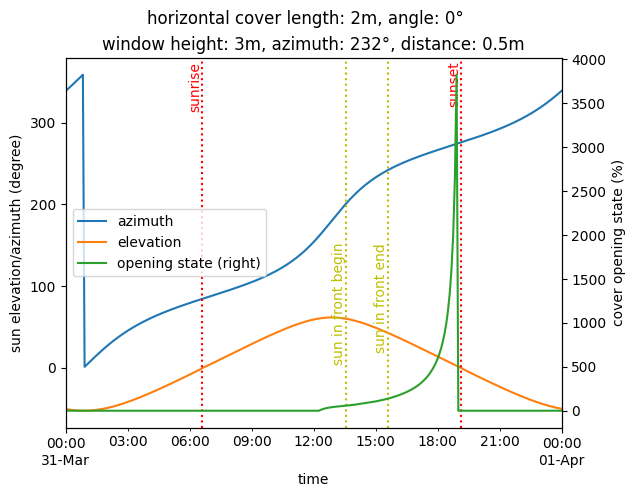

In [4]:
# Horizontal (awning) cover
window_height = 3
shaded_area = 0.5
cover_awning_length = 2
cover_awning_angle = 0

horiz_vert_config = VerticalConfig(distance=shaded_area, h_win=window_height)
horiz_config = HorizontalConfig(awn_length=cover_awning_length, awn_angle=cover_awning_angle)


def compute_horizontal_position(row):
    """Compute horizontal cover position for a single time step."""
    _sun = SunData(timezone, astral_location, astral_elevation)
    cover = AdaptiveHorizontalCover(
        logger=mocked_logger,
        sol_azi=row["azimuth"],
        sol_elev=row["elevation"],
        sun_data=_sun,
        config=cover_config,
        vert_config=horiz_vert_config,
        horiz_config=horiz_config,
    )
    return cover.calculate_percentage(), cover.valid


sun_df[["opening state", "sun_is_on"]] = sun_df.apply(
    compute_horizontal_position, axis=1, result_type="expand"
)

sun_in_front_begin = sun_df[sun_df["sun_is_on"]].iloc[0].name.to_pydatetime()
sun_in_front_end = sun_df[sun_df["sun_is_on"]].iloc[-1].name.to_pydatetime()

plot(f"horizontal cover length: {cover_awning_length}m, angle: {cover_awning_angle}°")

plt.savefig("outputs/horizontal_cover_plot.png", dpi=150, bbox_inches="tight")
print("Saved horizontal cover plot to outputs/horizontal_cover_plot.png")  # noqa: T201